# Modelamiento Supervisado: Regresión y Clasificación

**Caso de Estudio:** Ecommerce Customer Dataset
**Asignatura:** MLY1101 — Machine Learning
**Laboratorio de Modelamiento Supervisado: Regresión y Clasificación**

---

## Descripción

Este notebook corresponde a las **Fases 4 y 5 (Modelado y Evaluación)** de la metodología
CRISP-DM y desarrolla los pasos 2 y 3 del laboratorio. El paso 1 (carga, preparación y encoding
de las variables) está en [`preprocesamiento.ipynb`](preprocesamiento.ipynb).

- **Paso 2 — Clasificación:** predecir si un cliente abandonará la empresa (Exited).
- **Paso 3 — Regresión:** estimar el saldo de un cliente (Balance).

---

## Requisitos de Software

Este notebook fue desarrollado con Python 3.12. Las versiones exactas están fijadas en
[`requirements.txt`](../requirements.txt):

- pandas 2.3.3
- numpy 2.0.2
- matplotlib 3.9.4
- scipy 1.15.3
- scikit-learn 1.6.1 (como mínimo 1.4, que es la versión que incorpora `root_mean_squared_error`)

# Importación de librerías

In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('bmh')

from scipy import stats
from scipy.stats import randint
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, accuracy_score, average_precision_score, brier_score_loss,
                             f1_score, mean_absolute_error, precision_recall_curve, precision_score, r2_score,
                             recall_score, roc_auc_score, root_mean_squared_error)
from sklearn.model_selection import (GridSearchCV, KFold, RandomizedSearchCV, StratifiedKFold,
                                     cross_val_predict, cross_validate, train_test_split)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Advertencia espuria de numpy con la librería de cálculo de macOS; no afecta los resultados.
# Se silencia también en los procesos paralelos (n_jobs=-1), que no heredan el filtro de warnings.
warnings.filterwarnings('ignore', message='.*encountered in matmul', category=RuntimeWarning)
os.environ['PYTHONWARNINGS'] = ','.join(
    f'ignore:{problema} encountered in matmul:RuntimeWarning'
    for problema in ['divide by zero', 'overflow', 'invalid value']
)

os.makedirs('../images', exist_ok=True)
SEMILLA = 42

# Reconstrucción de la preparación de datos

Se reproducen, sin cambios, la carga, las variables derivadas, la partición y el pipeline de
preparación de [`preprocesamiento.ipynb`](preprocesamiento.ipynb), para que este notebook se
pueda ejecutar por sí solo. El centro de distancia_edad_riesgo se calcula después de la
partición, solo con el conjunto de entrenamiento. La justificación de cada decisión está en ese notebook.

Dos diferencias respecto de la versión anterior de este notebook:

- El OneHotEncoder usa `handle_unknown='error'` (la justificación está en [`preprocesamiento.ipynb`](preprocesamiento.ipynb), paso 4).
- `modelo_completo` trabaja sobre una **copia sin entrenar** del estimador (`clone`). Sin esto, si el mismo objeto se usa en dos pipelines, entrenar el segundo sobrescribe al primero, y el primero queda roto (falla al predecir porque espera otras columnas).

In [2]:
df = pd.read_csv('../data/ecommerce_customer_data.csv')
df = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

df['tiene_saldo'] = (df['Balance'] > 0).astype(int)

features_num = ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary', 'distancia_edad_riesgo']
features_cat = ['Geography', 'Gender', 'NumOfProducts']
features_bin = ['HasCrCard', 'IsActiveMember', 'tiene_saldo']

features_num_reg = [col for col in features_num if col != 'Balance']
features_bin_reg = [col for col in features_bin if col != 'tiene_saldo']

# distancia_edad_riesgo todavía no existe: se agrega después de la partición
features_base = [col for col in features_num + features_cat + features_bin if col != 'distancia_edad_riesgo']
X = df[features_base]
y_clf = df['Exited']
y_reg = df['Balance']

X_train, X_test, y_clf_train, y_clf_test, y_reg_train, y_reg_test = train_test_split(
    X, y_clf, y_reg, test_size=0.2, stratify=y_clf, random_state=SEMILLA
)

# El centro de la U invertida se aprende de Exited, así que se elige solo con el entrenamiento
correlacion_por_centro = {c: (X_train['Age'] - c).abs().corr(y_clf_train) for c in range(40, 66)}
CENTRO_EDAD = max(correlacion_por_centro, key=lambda c: abs(correlacion_por_centro[c]))
X_train = X_train.assign(distancia_edad_riesgo=(X_train['Age'] - CENTRO_EDAD).abs())
X_test = X_test.assign(distancia_edad_riesgo=(X_test['Age'] - CENTRO_EDAD).abs())

print(f'Entrenamiento: {X_train.shape} | Prueba: {X_test.shape} | Centro de edad: {CENTRO_EDAD} años')

Entrenamiento: (8000, 12) | Prueba: (2000, 12) | Centro de edad: 55 años


In [3]:
class CorrelationFilter(BaseEstimator, TransformerMixin):
    """
    Elimina variables con alta correlación (multicolinealidad). Las columnas a eliminar se
    aprenden en fit (conjunto de entrenamiento) y se aplican igual en transform.
    """
    def __init__(self, threshold=0.9):
        self.threshold = threshold

    def fit(self, X, y=None):
        X_df = pd.DataFrame(X)
        corr_matrix = X_df.corr().abs()
        upper = corr_matrix.where(
            np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
        )
        self.columns_to_drop_ = [
            col for col in upper.columns if any(upper[col] > self.threshold)
        ]
        return self

    def transform(self, X):
        return pd.DataFrame(X).drop(columns=self.columns_to_drop_, errors='ignore')


def construir_pipeline_preparacion(num_cols, cat_cols, bin_cols):
    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler())
    ])

    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot',  OneHotEncoder(drop='first', handle_unknown='error', sparse_output=False))
    ])

    preprocesador = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer,     num_cols),
            ('cat', categorical_transformer, cat_cols),
            ('bin', 'passthrough',           bin_cols)
        ],
        remainder='drop'
    ).set_output(transform='pandas')

    return Pipeline(steps=[
        ('preprocesador', preprocesador),
        ('colinealidad',  CorrelationFilter(threshold=0.9))
    ])


def modelo_completo(num_cols, cat_cols, bin_cols, estimador):
    """
    Pipeline de preparación + modelo: se entrena todo junto solo con el conjunto de entrenamiento.
    Usa una copia sin entrenar del estimador (clone), para que dos pipelines nunca compartan
    el mismo modelo entrenado.
    """
    return Pipeline(steps=[
        ('preparacion', construir_pipeline_preparacion(num_cols, cat_cols, bin_cols)),
        ('modelo',      clone(estimador))
    ])

# Paso 2 — Clasificación: predecir el abandono (Exited)

**Variable objetivo:** Exited (1 = el cliente abandonó, 0 = se mantuvo). **Características:** el
resto de las variables. La partición entrenamiento/prueba (80/20) ya se hizo arriba, estratificada
por Exited para mantener el 20,4% de abandono en ambos conjuntos.

Se comparan tres modelos:

- **Regresión logística:** modelo lineal, simple e interpretable.
- **Árbol de decisión:** una serie de reglas del tipo "si tiene más de 50 años y está inactivo,
  entonces…". Capta relaciones que no son lineales y combinaciones entre variables, como el efecto
  conjunto de la edad y la actividad que mostró el EDA (Sección 4.4), y se puede leer directamente.
- **Random Forest:** conjunto de cientos de árboles de decisión, cada uno entrenado con una parte
  distinta de los datos. Promediarlos corrige la inestabilidad de un árbol individual, a cambio de
  perder la posibilidad de leerlo como reglas.

Solo el 20,4% de los clientes abandona (EDA, Sección 4.1). Ese desbalance **no** se corrige con
class_weight='balanced': esa opción le da más peso a los abandonos al entrenar, pero a cambio
distorsiona las probabilidades, y el modelo pasa a estimar un abandono promedio muy superior al
real (se mide en la Sección 2.3). Como la decisión final sale de un umbral elegido con validación
cruzada, el desbalance se maneja ahí: bajar el umbral cumple el mismo papel que darles más peso
a los abandonos, sin perder probabilidades interpretables.

**Cómo se evalúa.** Un clasificador no entrega directamente "abandona / se mantiene": entrega una
*probabilidad* de abandono, y la decisión sale de compararla con un **umbral** (0,5 por defecto).
Hay dos preguntas distintas que no se deben mezclar:

1. **¿Qué modelo ordena mejor a los clientes según su riesgo?** Se responde con métricas que no
   dependen del umbral:
   - **ROC-AUC:** probabilidad de que el modelo le asigne más riesgo a un cliente que abandona que
     a uno que se mantiene (0,5 = azar, 1 = perfecto).
   - **PR-AUC** (precisión promedio): resume la precisión en todos los niveles de recall. Es la más
     informativa con clases desbalanceadas; un modelo al azar obtiene 0,204 (el % de abandono).
2. **¿Con qué umbral se usa el modelo?** Es una decisión de negocio: bajar el umbral detecta más
   abandonos a costa de más falsas alarmas.

Antes de las dos, se ajustan los **hiperparámetros** de cada modelo. Ninguna de estas decisiones
se toma con el conjunto de prueba: todas se toman con **validación cruzada estratificada de 5
partes sobre el entrenamiento**, y la prueba se usa una sola vez, al final, para medir el
desempeño de lo que ya se eligió.

**Métricas con umbral** (para el resultado final):

- **Accuracy:** % de clientes clasificados correctamente. Por el desbalance no basta por sí sola:
  predecir siempre "se mantiene" ya da 79,6%.
- **Recall:** de los clientes que realmente abandonan, qué % detecta el modelo.
- **Precisión:** de los clientes que el modelo marca como "abandonará", qué % realmente abandona.
- **F1:** resume en un solo número el equilibrio entre precisión y recall.

## 2.1 Ajuste de hiperparámetros

Los hiperparámetros son opciones del modelo que no se aprenden de los datos, sino que se fijan antes
de entrenar: por ejemplo, cuántos árboles tiene el Random Forest o cuánta regularización aplica la
regresión logística. Se ajustan con dos herramientas de scikit-learn que hacen lo mismo de distinta
forma:

- **GridSearchCV** prueba *todas* las combinaciones de una grilla. Conviene cuando el espacio es
  chico. Se usa en la **regresión logística**, que tiene dos hiperparámetros relevantes: C (el
  inverso de la fuerza de la regularización: un C chico simplifica más el modelo) y el tipo de
  penalización (l1 puede dejar coeficientes en 0; l2 solo los achica). Son 6 × 2 = 12 combinaciones. También se usa en el
  **árbol de decisión**, con dos hiperparámetros que controlan qué tan complejo es: max_depth (la
  profundidad máxima, es decir, cuántas preguntas encadenadas puede hacer) y min_samples_leaf (el
  mínimo de clientes en cada hoja). Son 7 × 5 = 35 combinaciones.
- **RandomizedSearchCV** prueba un número fijo de combinaciones elegidas al azar. Conviene cuando
  el espacio es grande y la grilla completa sería demasiado costosa. Se usa en el **Random Forest**,
  que tiene cuatro hiperparámetros con muchos valores posibles (miles de combinaciones), de las que
  se prueban 30:
  - n_estimators: cantidad de árboles.
  - max_depth: profundidad máxima de cada árbol.
  - min_samples_leaf: mínimo de clientes en cada hoja (valores altos dan árboles más simples).
  - max_features: fracción de variables que cada árbol puede considerar en cada división.

Las tres búsquedas siguen las mismas reglas:

- **Validación cruzada estratificada de 5 partes sobre el entrenamiento.** Cada combinación se
  entrena 5 veces con 4 partes y se evalúa en la restante, siempre con el mismo 20,4% de abandono.
  La prueba no se toca.
- **La búsqueda recorre el pipeline completo** (preparación + modelo): el escalado, el one-hot y el
  filtro de colinealidad se reajustan en cada partición, así que nada de la parte de validación se
  filtra al entrenamiento. Por eso los hiperparámetros llevan el prefijo del paso (modelo__C).
- **Gana la combinación con mejor PR-AUC** (refit='PR-AUC'), la métrica más informativa con clases
  desbalanceadas; el ROC-AUC también se registra. Al terminar, la búsqueda reentrena la mejor
  combinación con todo el entrenamiento.
- **Las tres usan las mismas 5 particiones** (el mismo objeto cv), lo que permite comparar los
  modelos partición por partición (Sección 2.2).

In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEMILLA)
metricas_cv = {'ROC-AUC': 'roc_auc', 'PR-AUC': 'average_precision'}

# Regresión logística: espacio chico -> GridSearchCV prueba las 12 combinaciones.
# solver='liblinear' admite las dos penalizaciones (l1 y l2).
busqueda_logistica = GridSearchCV(
    modelo_completo(features_num, features_cat, features_bin,
                    LogisticRegression(solver='liblinear', max_iter=1000)),
    param_grid={
        'modelo__C':       [0.001, 0.01, 0.1, 1, 10, 100],
        'modelo__penalty': ['l1', 'l2'],
    },
    scoring=metricas_cv, refit='PR-AUC', cv=cv, n_jobs=-1,
)
busqueda_logistica.fit(X_train, y_clf_train)

print(f'Mejor combinación: {busqueda_logistica.best_params_}')
print('PR-AUC (media de las 5 particiones) de cada combinación:')
(pd.DataFrame(busqueda_logistica.cv_results_)
 .pivot_table(index='param_modelo__C', columns='param_modelo__penalty', values='mean_test_PR-AUC')
 .round(4))

Mejor combinación: {'modelo__C': 10, 'modelo__penalty': 'l1'}
PR-AUC (media de las 5 particiones) de cada combinación:


param_modelo__penalty,l1,l2
param_modelo__C,,
0.001,0.2037,0.5793
0.010,0.6105,0.6341
0.100,0.6624,0.6602
1.000,0.6674,0.6665
10.000,0.6674,0.6674
100.000,0.6674,0.6673


- Con C muy chico (0,001), la regularización es tan fuerte que el modelo se queda casi sin
  información: con l1 todos los coeficientes quedan en 0 y el PR-AUC cae al nivel del azar (0,204).
- Desde C = 1 en adelante el resultado prácticamente no cambia (0,6665 a 0,6674): con 8.000 clientes
  y 14 columnas, la regresión logística casi no sobreajusta, así que regularizarla no le aporta nada.
- La mejor combinación es C = 10 con penalización l1, pero su ventaja sobre C = 1 está en el cuarto
  decimal: en la práctica, la configuración por defecto (C = 1, l2) ya era adecuada.

In [5]:
# Random Forest: espacio grande -> RandomizedSearchCV prueba 30 combinaciones al azar
espacio_rf = {
    'modelo__n_estimators':     randint(200, 601),
    'modelo__max_depth':        [None, 6, 8, 10, 12, 16],
    'modelo__min_samples_leaf': randint(1, 31),
    'modelo__max_features':     ['sqrt', 0.3, 0.5, 0.7],
}
busqueda_rf = RandomizedSearchCV(
    modelo_completo(features_num, features_cat, features_bin, RandomForestClassifier(random_state=SEMILLA)),
    param_distributions=espacio_rf, n_iter=30,
    scoring=metricas_cv, refit='PR-AUC', cv=cv, n_jobs=-1, random_state=SEMILLA,
)
busqueda_rf.fit(X_train, y_clf_train)

resultados_rf = pd.DataFrame(busqueda_rf.cv_results_).sort_values('rank_test_PR-AUC')
print(f'Mejor combinación: {busqueda_rf.best_params_}')
print(f"PR-AUC de las 30 combinaciones: de {resultados_rf['mean_test_PR-AUC'].min():.3f} "
      f"a {resultados_rf['mean_test_PR-AUC'].max():.3f}")
print('Las 8 mejores combinaciones:')
resultados_rf[['param_modelo__n_estimators', 'param_modelo__max_depth', 'param_modelo__min_samples_leaf',
               'param_modelo__max_features', 'mean_test_ROC-AUC', 'mean_test_PR-AUC']].head(8).round(4)

Mejor combinación: {'modelo__max_depth': 10, 'modelo__max_features': 'sqrt', 'modelo__min_samples_leaf': 1, 'modelo__n_estimators': 513}
PR-AUC de las 30 combinaciones: de 0.663 a 0.684
Las 8 mejores combinaciones:


,param_modelo__n_estimators,param_modelo__max_depth,param_modelo__min_samples_leaf,param_modelo__max_features,mean_test_ROC-AUC,mean_test_PR-AUC
6,513,10,1,sqrt,0.8588,0.6840
5,585,10,6,0.3,0.8601,0.6819
13,473,12,7,sqrt,0.8585,0.6803
1,321,12,7,sqrt,0.8580,0.6799
22,469,10,10,0.3,0.8592,0.6795
20,509,16,4,0.3,0.8574,0.6794
28,543,None,9,0.5,0.8587,0.6773
2,287,8,11,0.5,0.8584,0.6770


- La mejor combinación usa 513 árboles con profundidad máxima 10, hojas de 1 cliente y la raíz
  cuadrada del total de variables en cada división. Aquí el límite de profundidad cumple el papel de
  regularización que en otras combinaciones cumplen las hojas grandes.
- Las 30 combinaciones quedan entre 0,663 y 0,684 de PR-AUC, y las 8 mejores a menos de 0,007 entre
  sí: el Random Forest es poco sensible a sus hiperparámetros.
- La configuración que se usaba antes del ajuste (300 árboles, hojas de 5 clientes y
  class_weight='balanced') llegaba a un PR-AUC de 0,672: el ajuste suma algo más de 1 punto.

In [6]:
# Árbol de decisión: dos hiperparámetros con pocos valores -> GridSearchCV prueba las 35 combinaciones
busqueda_arbol = GridSearchCV(
    modelo_completo(features_num, features_cat, features_bin, DecisionTreeClassifier(random_state=SEMILLA)),
    param_grid={
        'modelo__max_depth':        [3, 4, 5, 6, 8, 10, None],
        'modelo__min_samples_leaf': [1, 10, 30, 60, 100],
    },
    scoring=metricas_cv, refit='PR-AUC', cv=cv, n_jobs=-1,
)
busqueda_arbol.fit(X_train, y_clf_train)

print(f'Mejor combinación: {busqueda_arbol.best_params_}')
print('PR-AUC (media de las 5 particiones) de cada combinación:')
(pd.DataFrame(busqueda_arbol.cv_results_)
 .assign(param_modelo__max_depth=lambda d: d['param_modelo__max_depth'].astype(str))
 .pivot_table(index='param_modelo__max_depth', columns='param_modelo__min_samples_leaf', values='mean_test_PR-AUC')
 .reindex(['3', '4', '5', '6', '8', '10', 'None'])
 .round(4))

Mejor combinación: {'modelo__max_depth': 8, 'modelo__min_samples_leaf': 60}
PR-AUC (media de las 5 particiones) de cada combinación:


param_modelo__min_samples_leaf,1,10,30,60,100
param_modelo__max_depth,,,,,
3,0.5246,0.5246,0.5246,0.5188,0.5207
4,0.5704,0.5704,0.5817,0.5788,0.5775
5,0.5941,0.6092,0.6197,0.6133,0.6071
6,0.5955,0.6223,0.6305,0.6305,0.6203
8,0.5610,0.6135,0.6322,0.6393,0.6226
10,0.5050,0.5931,0.6307,0.6390,0.6234
None,0.3397,0.5705,0.6296,0.6387,0.6234


- La mejor combinación es un árbol de **profundidad 8 con hojas de al menos 60 clientes** (PR-AUC
  0,639).
- La tabla muestra el equilibrio típico de un árbol. Con poca profundidad (3 o 4) es demasiado simple
  y no capta lo suficiente (PR-AUC 0,52 a 0,58). Con mucha profundidad y hojas chicas, se aprende de
  memoria a los clientes de entrenamiento: sin límite de profundidad y con hojas de 1 cliente, el
  PR-AUC cae a 0,34, apenas por encima del azar (0,204).
- Las hojas grandes (30 a 60 clientes) frenan ese sobreajuste aunque el árbol sea profundo: obligan
  a que cada regla se cumpla en un grupo de clientes, no en uno solo.

## 2.2 Comparación de los modelos ajustados

Los tres modelos se evaluaron con las mismas 5 particiones. Para compararlos no basta con ver si la
diferencia de medias supera la desviación entre particiones: esa desviación mide sobre todo qué tan
difícil le tocó a cada partición, y esa dificultad la comparten los dos modelos. Lo que corresponde
es una **comparación pareada**: restar los puntajes de dos modelos *en cada partición* y ver si
la diferencia se mantiene.

Para medirlo se usa una prueba t pareada con la **corrección de Nadeau y Bengio**: las 5 particiones
comparten gran parte de sus datos de entrenamiento, así que sus resultados no son independientes y
la prueba t clásica exageraría la confianza.

In [7]:
def puntajes_por_particion(busqueda, metrica):
    """Puntaje de la mejor combinación de una búsqueda en cada una de las particiones."""
    i = busqueda.best_index_
    return np.array([busqueda.cv_results_[f'split{k}_test_{metrica}'][i] for k in range(busqueda.n_splits_)])


def t_test_corregido(diferencias, proporcion_prueba):
    """
    Prueba t pareada con la corrección de Nadeau y Bengio (2003). proporcion_prueba es el tamaño de
    la parte de validación dividido por el de entrenamiento (1/4 con 5 particiones).
    """
    k = len(diferencias)
    t = diferencias.mean() / np.sqrt((1 / k + proporcion_prueba) * diferencias.var(ddof=1))
    return t, 2 * stats.t.sf(abs(t), df=k - 1)


busquedas_clf = {'Regresión logística': busqueda_logistica, 'Random Forest': busqueda_rf,
                 'Árbol de decisión': busqueda_arbol}

filas = []
for nombre, busqueda in busquedas_clf.items():
    fila = {'modelo': nombre}
    for metrica in metricas_cv:
        puntajes = puntajes_por_particion(busqueda, metrica)
        fila[f'{metrica} (media)'] = puntajes.mean()
        fila[f'{metrica} (desv.)'] = puntajes.std()
    filas.append(fila)

print(f'PR-AUC de un modelo al azar (= % de abandono en entrenamiento): {y_clf_train.mean():.3f}\n')
for rival in ['Regresión logística', 'Árbol de decisión']:
    for metrica in metricas_cv:
        diferencia = puntajes_por_particion(busqueda_rf, metrica) - puntajes_por_particion(busquedas_clf[rival], metrica)
        t, p = t_test_corregido(diferencia, proporcion_prueba=1 / (cv.get_n_splits() - 1))
        print(f'{metrica}: Random Forest - {rival} en cada partición = {np.round(diferencia, 3)}')
        print(f'         diferencia media {diferencia.mean():+.3f} | t corregido = {t:.2f} | p = {p:.3f}')
pd.DataFrame(filas).set_index('modelo').round(3)

PR-AUC de un modelo al azar (= % de abandono en entrenamiento): 0.204

ROC-AUC: Random Forest - Regresión logística en cada partición = [0.016 0.011 0.004 0.01  0.012]
         diferencia media +0.011 | t corregido = 3.72 | p = 0.020
PR-AUC: Random Forest - Regresión logística en cada partición = [0.015 0.029 0.014 0.006 0.018]
         diferencia media +0.017 | t corregido = 2.98 | p = 0.041
ROC-AUC: Random Forest - Árbol de decisión en cada partición = [0.018 0.025 0.015 0.016 0.017]
         diferencia media +0.018 | t corregido = 7.11 | p = 0.002
PR-AUC: Random Forest - Árbol de decisión en cada partición = [0.047 0.049 0.042 0.05  0.036]
         diferencia media +0.045 | t corregido = 11.27 | p = 0.000


,ROC-AUC (media),ROC-AUC (desv.),PR-AUC (media),PR-AUC (desv.)
modelo,,,,
Regresión logística,0.848,0.013,0.667,0.019
Random Forest,0.859,0.012,0.684,0.023
Árbol de decisión,0.841,0.010,0.639,0.023


- Los tres modelos están muy por encima del azar (PR-AUC de 0,667 la logística, 0,684 el Random
  Forest y 0,639 el árbol, contra 0,204).
- El **Random Forest** le gana a la **regresión logística** en las 5 particiones y en las dos
  métricas, en promedio por +0,011 de ROC-AUC y +0,017 de PR-AUC. La prueba corregida indica que la
  ventaja es consistente (p = 0,020 en ROC-AUC y p = 0,041 en PR-AUC). Si se hubiera comparado con la
  desviación entre particiones (0,012 a 0,023), se habría concluido, por error, que la diferencia no
  se distingue del azar.
- El **Random Forest** le gana al **árbol de decisión** con más claridad: +0,018 de ROC-AUC y
  +0,045 de PR-AUC, en las 5 particiones (p = 0,002 y p < 0,001). Es lo esperable: el Random Forest
  promedia cientos de árboles y compensa los errores de cada uno. El árbol queda incluso por debajo
  de la regresión logística.
- Aun así, la ventaja del Random Forest sobre la logística es **pequeña** y puede estar algo inflada:
  el Random Forest se eligió entre 30 combinaciones y la logística entre 12, y la mejor de muchas
  combinaciones siempre queda un poco por encima de lo que logrará con clientes nuevos. La evaluación
  en prueba (Sección 2.6) es la que lo confirma o lo descarta.

Se elige el **Random Forest** como modelo principal. La regresión logística sigue siendo una
alternativa razonable si se prioriza poder explicar cada predicción, y el árbol de decisión, si se
necesita mostrar las reglas de decisión al negocio (ver su diagrama en la Sección 2.6).

## 2.3 Predicciones fuera de pliegue y calibración

El resto de las decisiones se toma con predicciones *fuera de pliegue* (out-of-fold): cada cliente
de entrenamiento recibe la probabilidad de un modelo que no lo vio al entrenar, de modo que el
análisis no toca el conjunto de prueba.

Lo primero es revisar si esas probabilidades se pueden leer como tales: si el modelo le asigna 30% a
un grupo de clientes, ¿abandonan cerca de 30 de cada 100? Eso se llama **calibración**, y se mide con:

- **Abandono promedio estimado:** en un modelo calibrado, el promedio de sus probabilidades se
  parece a la tasa real de abandono (20,4%).
- **Brier score:** el error cuadrático medio entre la probabilidad y lo que ocurrió (0 o 1). Mientras
  más bajo, mejor.

Cada modelo se compara con el mismo modelo entrenado con class_weight='balanced'.

In [8]:
# Los mejores pipelines de cada búsqueda (cross_val_predict los vuelve a entrenar en cada partición)
modelos_clasificacion = {nombre: busqueda.best_estimator_ for nombre, busqueda in busquedas_clf.items()}

prob_oof = {
    nombre: cross_val_predict(modelo, X_train, y_clf_train, cv=cv, method='predict_proba', n_jobs=-1)[:, 1]
    for nombre, modelo in modelos_clasificacion.items()
}

filas = []
for nombre, modelo in modelos_clasificacion.items():
    modelo_balanceado = clone(modelo).set_params(modelo__class_weight='balanced')
    prob_balanceado = cross_val_predict(modelo_balanceado, X_train, y_clf_train, cv=cv,
                                        method='predict_proba', n_jobs=-1)[:, 1]
    for version, prob in [('sin class_weight', prob_oof[nombre]), ("class_weight='balanced'", prob_balanceado)]:
        filas.append({
            'modelo':                     nombre,
            'version':                    version,
            'abandono promedio estimado': prob.mean(),
            'Brier':                      brier_score_loss(y_clf_train, prob),
            'ROC-AUC':                    roc_auc_score(y_clf_train, prob),
        })

print(f'Abandono real en entrenamiento: {y_clf_train.mean():.3f}')
pd.DataFrame(filas).set_index(['modelo', 'version']).round(3)

Abandono real en entrenamiento: 0.204


abandono promedio estimado  \
modelo              version                                               
Regresión logística sin class_weight                              0.204   
                    class_weight='balanced'                       0.391   
Random Forest       sin class_weight                              0.203   
                    class_weight='balanced'                       0.318   
Árbol de decisión   sin class_weight                              0.205   
                    class_weight='balanced'                       0.376   

                                             Brier  ROC-AUC  
modelo              version                                  
Regresión logística sin class_weight         0.108    0.848  
                    class_weight='balanced'  0.155    0.848  
Random Forest       sin class_weight         0.105    0.858  
                    class_weight='balanced'  0.124    0.854  
Árbol de decisión   sin class_weight         0.111    0.840  
                    class_weight='balanced'  0.161    0.832

- **Sin class_weight**, el abandono promedio estimado es 0,204 (logística), 0,203 (Random Forest) y
  0,205 (árbol), igual al real: las probabilidades se pueden leer como probabilidades.
- **Con class_weight='balanced'**, la logística estima en promedio 0,391, el Random Forest 0,318 y
  el árbol 0,376, entre 1,6 y 1,9 veces el abandono real, y el Brier empeora en los tres (por
  ejemplo, 0,108 → 0,155 en la logística y 0,105 → 0,124 en el Random Forest).
- El ROC-AUC queda igual (0,848 en la logística) o baja levemente (0,858 → 0,854 en el Random
  Forest): class_weight no mejora la capacidad de ordenar a los clientes según su riesgo. Solo
  desplaza las probabilidades hacia arriba, que equivale a bajar el umbral.

Por eso los modelos se entrenan sin class_weight y el desbalance se maneja con el umbral
(Sección 2.5). Así, además, las probabilidades se pueden usar directamente si en algún momento se
calcula el costo esperado de cada decisión.

## 2.4 ¿La diferencia entre modelos viene del modelo o del umbral?

Con un mismo umbral, dos modelos pueden quedar en puntos de operación distintos (uno detecta más
abandonos y el otro genera menos falsas alarmas) solo porque reparten sus probabilidades de forma
distinta. Para separar el efecto del modelo del efecto del umbral, se comparan los modelos **con el
mismo recall**, usando las predicciones fuera de pliegue de la Sección 2.3.

Precisión de cada modelo con un mismo recall (entrenamiento, fuera de pliegue):
               Regresión logística  Random Forest  Árbol de decisión
recall mínimo                                                       
0.60                         0.612          0.629              0.584
0.65                         0.576          0.581              0.544
0.70                         0.516          0.537              0.493
0.75                         0.476          0.486              0.460
0.80                         0.430          0.444              0.424 

Con el umbral por defecto (0,5):
  Regresión logística  recall 0.445 | precisión 0.725
  Random Forest        recall 0.444 | precisión 0.777
  Árbol de decisión    recall 0.478 | precisión 0.711


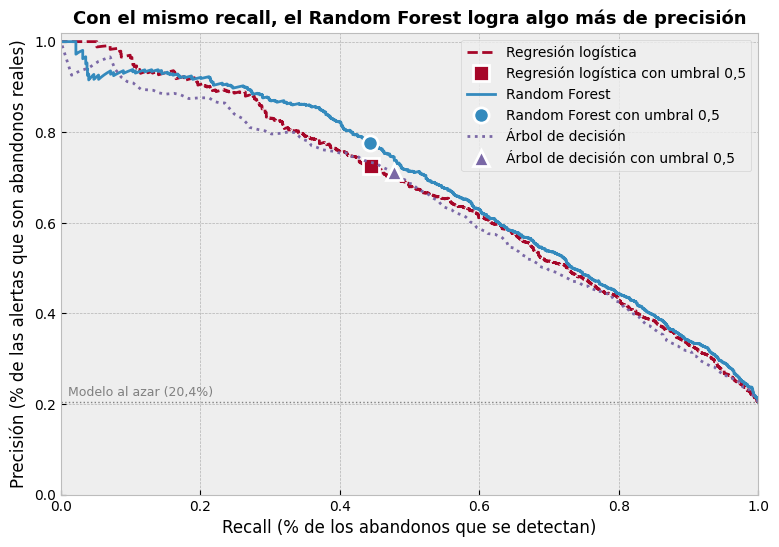

In [9]:
def precision_con_recall(y_real, prob, recall_minimo):
    """Mejor precisión que alcanza el modelo detectando al menos `recall_minimo` de los abandonos."""
    precision, recall, _ = precision_recall_curve(y_real, prob)
    return precision[recall >= recall_minimo].max()


niveles_recall = [0.60, 0.65, 0.70, 0.75, 0.80]
tabla_recall = pd.DataFrame(
    {nombre: [precision_con_recall(y_clf_train, prob, r) for r in niveles_recall]
     for nombre, prob in prob_oof.items()},
    index=pd.Index(niveles_recall, name='recall mínimo'),
)
print('Precisión de cada modelo con un mismo recall (entrenamiento, fuera de pliegue):')
print(tabla_recall.round(3), '\n')

print('Con el umbral por defecto (0,5):')
for nombre, prob in prob_oof.items():
    pred = prob >= 0.5
    print(f'  {nombre:20s} recall {recall_score(y_clf_train, pred):.3f} | '
          f'precisión {precision_score(y_clf_train, pred):.3f}')

fig, ax = plt.subplots(figsize=(9, 6))
estilos = {'Regresión logística': ('#A60628', '--', 's'), 'Random Forest': ('#348ABD', '-', 'o'),
           'Árbol de decisión': ('#7A68A6', ':', '^')}
for nombre, prob in prob_oof.items():
    color, linea, marcador = estilos[nombre]
    precision, recall, _ = precision_recall_curve(y_clf_train, prob)
    ax.plot(recall, precision, color=color, linestyle=linea, linewidth=2, label=nombre)
    pred = prob >= 0.5
    ax.plot(recall_score(y_clf_train, pred), precision_score(y_clf_train, pred), marker=marcador,
            markersize=11, color=color, markeredgecolor='white', markeredgewidth=2, linestyle='none',
            label=f'{nombre} con umbral 0,5')
ax.axhline(y_clf_train.mean(), color='gray', linestyle=':', linewidth=1)
ax.text(0.01, y_clf_train.mean() + 0.015, 'Modelo al azar (20,4%)', color='gray', fontsize=9)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.set_xlabel('Recall (% de los abandonos que se detectan)')
ax.set_ylabel('Precisión (% de las alertas que son abandonos reales)')
ax.set_title('Con el mismo recall, el Random Forest logra algo más de precisión', fontsize=13, fontweight='bold')
ax.legend(loc='upper right')
plt.savefig('../images/clasificacion_curva_precision_recall.png', dpi=150, bbox_inches='tight')
plt.show()

- **Con el umbral 0,5**, la logística y el Random Forest detectan el mismo porcentaje de abandonos
  (44%), con precisión 0,73 y 0,78; el árbol detecta algo más (48%) con precisión 0,71. Son los
  marcadores del gráfico. Están cerca porque los tres están calibrados (Sección 2.3): 0,5 significa
  casi lo mismo en todos. Con class_weight='balanced' no ocurriría, porque cada modelo infla sus
  probabilidades en distinta medida.
- **Con el mismo recall**, el Random Forest logra más precisión que los otros dos en todos los
  niveles de la tabla (por ejemplo, 0,486 contra 0,476 de la logística y 0,460 del árbol, detectando
  el 75% de los abandonos). El árbol queda por debajo de la logística en todos los niveles.

**Conclusión:** la ventaja del Random Forest es real pero chica, y se mantiene en cualquier punto
de operación. La pregunta "¿detectar más abandonos o generar menos falsas alarmas?" no se responde
eligiendo un modelo, sino eligiendo el umbral.

## 2.5 Elección del umbral

El objetivo de negocio es *"identificar qué clientes se encuentran en riesgo de abandonar la
institución para inyectarles una campaña de fidelización"*. Para eso la métrica principal es el
**recall**: un cliente en riesgo que no se detecta se pierde sin haber recibido la campaña, y ese es
el error más caro. Pero la **precisión hay que vigilarla**: si el modelo alerta a demasiados clientes
que no se iban a ir, la campaña deja de ser focalizada.

Como el caso no entrega los costos de cada error, se usa una regla explícita: **el umbral con mayor
recall entre los que logran una precisión de al menos 50%**, es decir, como máximo una falsa alarma
por cada abandono detectado. Se busca en pasos de 0,05 sobre las predicciones fuera de pliegue, así
que la prueba no se usa para elegirlo. Como referencia se muestra también el umbral que maximiza F1.
La tabla muestra, para el Random Forest, qué implica cada umbral.

In [10]:
umbrales = np.round(np.arange(0.10, 0.81, 0.05), 2)


def resumen_umbral(y_real, prob, umbral):
    pred = prob >= umbral
    return {
        'umbral':               umbral,
        'recall':               recall_score(y_real, pred),
        'precision':            precision_score(y_real, pred, zero_division=0),
        'f1':                   f1_score(y_real, pred),
        '% clientes alertados': pred.mean() * 100,
    }


tablas_umbral = {
    nombre: pd.DataFrame([resumen_umbral(y_clf_train, prob, u) for u in umbrales]).set_index('umbral')
    for nombre, prob in prob_oof.items()
}
# Criterio: priorizar el recall manteniendo la precisión bajo control. Se elige el umbral con
# mayor recall entre los que logran que al menos la mitad de las alertas sean reales.
PRECISION_MINIMA = 0.50
umbral_elegido = {
    nombre: tabla[tabla['precision'] >= PRECISION_MINIMA]['recall'].idxmax()
    for nombre, tabla in tablas_umbral.items()
}
umbral_max_f1 = {nombre: tabla['f1'].idxmax() for nombre, tabla in tablas_umbral.items()}

for nombre in tablas_umbral:
    print(f'{nombre}: umbral elegido (mayor recall con precisión >= {PRECISION_MINIMA:.0%}) = '
          f'{umbral_elegido[nombre]:.2f} | umbral de máximo F1 (referencia) = {umbral_max_f1[nombre]:.2f}')
print('\nRandom Forest: efecto del umbral (entrenamiento, fuera de pliegue)')
tablas_umbral['Random Forest'].round(3)

Regresión logística: umbral elegido (mayor recall con precisión >= 50%) = 0.25 | umbral de máximo F1 (referencia) = 0.30
Random Forest: umbral elegido (mayor recall con precisión >= 50%) = 0.25 | umbral de máximo F1 (referencia) = 0.35
Árbol de decisión: umbral elegido (mayor recall con precisión >= 50%) = 0.25 | umbral de máximo F1 (referencia) = 0.35

Random Forest: efecto del umbral (entrenamiento, fuera de pliegue)


,recall,precision,f1,% clientes alertados
umbral,,,,
0.10,0.915,0.333,0.488,56.012
0.15,0.829,0.417,0.555,40.575
0.20,0.760,0.477,0.586,32.450
0.25,0.701,0.537,0.608,26.600
0.30,0.639,0.589,0.613,22.100
0.35,0.583,0.649,0.615,18.312
0.40,0.526,0.694,0.598,15.425
0.45,0.480,0.738,0.581,13.250
0.50,0.444,0.777,0.565,11.638


- Con la regla de mayor recall y precisión de al menos 50%, el umbral elegido es **0,25 para los tres
  modelos**. Como referencia, el umbral que maximiza F1 sería 0,35 (Random Forest y árbol) y 0,30
  (regresión logística).
- Son menores que 0,5 porque, con probabilidades calibradas y solo un 20% de abandono, una
  probabilidad de 0,25 ya indica un riesgo mayor que el promedio. Bajar el umbral es justamente la
  forma de manejar el desbalance que reemplaza a class_weight.
- Elegir 0,25 en vez del máximo F1 casi no cuesta equilibrio: F1 es casi plano entre 0,25 y 0,35
  (0,608 a 0,615), pero el recall sube de 0,58 a 0,70.
- La tabla es la herramienta de decisión para el negocio. Con el Random Forest:
  - **Umbral 0,20:** detecta el 76% de los abandonos, pero alerta al 32,5% de la cartera, y menos
    de la mitad de las alertas son reales (precisión 0,48): no cumple la precisión mínima.
  - **Umbral 0,25 (elegido):** detecta el 70%, alerta al 26,6% de la cartera y el 54% de las
    alertas son reales.
  - **Umbral 0,35 (máximo F1):** detecta el 58%, alerta al 18,3% de la cartera y el 65% de las
    alertas son reales.
  - **Umbral 0,50:** detecta solo el 44%, pero el 78% de las alertas son reales, y alerta al 11,6%
    de la cartera.
- La precisión mínima de 50% es una decisión de negocio, no un estándar. Si se conocieran los costos
  (cuánto cuesta perder un cliente frente a cuánto cuesta una acción de retención), se elegiría el
  umbral que minimiza el costo total. scikit-learn ofrece `TunedThresholdClassifierCV` (desde la
  versión 1.5) para hacer esa búsqueda de forma automática.

## 2.6 Evaluación final en el conjunto de prueba

Con los hiperparámetros, el modelo y el umbral ya decididos, se evalúan los dos modelos **una sola
vez** en la prueba, cada uno con su umbral. No hace falta volver a entrenarlos: cada búsqueda ya
reentrenó su mejor combinación con todo el conjunto de entrenamiento. Se reportan los dos para
verificar que las conclusiones de la validación cruzada se sostienen con clientes nuevos.

In [11]:
predicciones_clf = {}
filas = []
for nombre, modelo in modelos_clasificacion.items():
    prob = modelo.predict_proba(X_test)[:, 1]
    pred = (prob >= umbral_elegido[nombre]).astype(int)
    predicciones_clf[nombre] = pred
    filas.append({
        'modelo':    nombre,
        'umbral':    umbral_elegido[nombre],
        'ROC-AUC':   roc_auc_score(y_clf_test, prob),
        'PR-AUC':    average_precision_score(y_clf_test, prob),
        'Brier':     brier_score_loss(y_clf_test, prob),
        'accuracy':  accuracy_score(y_clf_test, pred),
        'precision': precision_score(y_clf_test, pred),
        'recall':    recall_score(y_clf_test, pred),
        'f1':        f1_score(y_clf_test, pred),
    })

pd.DataFrame(filas).set_index('modelo').round(3)

,umbral,ROC-AUC,PR-AUC,Brier,accuracy,precision,recall,f1
modelo,,,,,,,,
Regresión logística,0.25,0.850,0.684,0.106,0.804,0.512,0.705,0.594
Random Forest,0.25,0.862,0.703,0.103,0.823,0.550,0.710,0.620
Árbol de decisión,0.25,0.841,0.641,0.111,0.816,0.537,0.695,0.606


- La prueba confirma la validación cruzada: el Random Forest queda por encima en ROC-AUC (0,862,
  contra 0,850 de la logística y 0,841 del árbol), PR-AUC (0,703 contra 0,684 y 0,641), Brier (0,103
  contra 0,106 y 0,111) y F1 (0,620 contra 0,594 y 0,606).
- Con el mismo umbral (0,25), los tres detectan casi la misma proporción de abandonos (recall de
  0,695 a 0,710), pero el Random Forest lo hace con más precisión (0,550, contra 0,512 de la
  logística y 0,537 del árbol): sus alertas son más certeras.
- La regla del umbral se cumple con clientes nuevos: el Random Forest detecta el 71% de los
  abandonos y el 55% de sus alertas son reales, por encima de la precisión mínima de 50%.
- Los tres superan a la referencia de predecir siempre "se mantiene" (accuracy 0,796, recall 0).
- El ROC-AUC y el PR-AUC de prueba quedan dentro del rango de la validación cruzada (PR-AUC del
  Random Forest: 0,703 en prueba contra 0,684 ± 0,023). No hay señales de sobreajuste ni de que el
  ajuste de hiperparámetros haya inflado las cifras de validación.

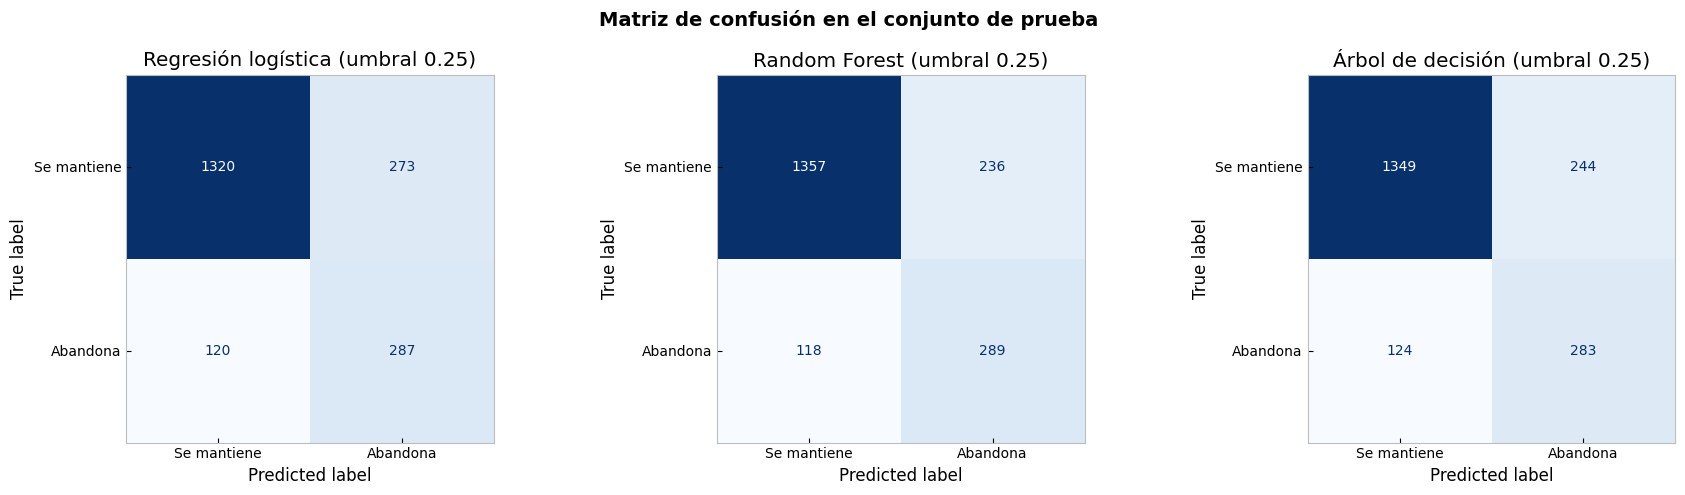

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (nombre, pred) in zip(axes, predicciones_clf.items()):
    ConfusionMatrixDisplay.from_predictions(y_clf_test, pred, display_labels=['Se mantiene', 'Abandona'],
                                            cmap='Blues', colorbar=False, ax=ax)
    ax.set_title(f'{nombre} (umbral {umbral_elegido[nombre]:.2f})')
    ax.grid(False)
plt.suptitle('Matriz de confusión en el conjunto de prueba', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/clasificacion_matriz_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

La matriz de confusión muestra los aciertos y errores en los 2.000 clientes de prueba (407
abandonaron):

| | Regresión logística | Random Forest | Árbol de decisión |
|---|---:|---:|---:|
| Abandonos detectados | 287 de 407 | 289 de 407 | 283 de 407 |
| Abandonos no detectados | 120 | 118 | 124 |
| Falsas alarmas (se marca "abandona" pero se mantiene) | 273 | 236 | 244 |

Los tres usan el umbral 0,25.

**¿Cuál conviene?** El **Random Forest**: detecta la mayor cantidad de abandonos (289) con la menor
cantidad de falsas alarmas (236). Además tiene una ventaja consistente en las métricas que no
dependen del umbral (Secciones 2.2 y 2.4).

Frente al umbral de máximo F1 (0,35), el umbral elegido detecta **47 abandonos más** (289 contra
242), a cambio de 103 falsas alarmas más (236 contra 133). Es el intercambio que busca el criterio:
priorizar el recall mientras la precisión se mantiene sobre 50%. Si la campaña de retención fuera
cara, convendría subir el umbral; si perder un cliente fuera mucho más caro que contactar a uno que
no se iba a ir, convendría bajarlo.

### ¿Cómo decide el árbol de decisión?

La ventaja del árbol frente a los otros dos modelos es que se puede leer como una serie de reglas.
El diagrama muestra sus primeros 3 niveles: en cada caja, la regla que separa a los clientes, el %
de clientes de entrenamiento que llega a ese punto y la proporción de abandono entre ellos.

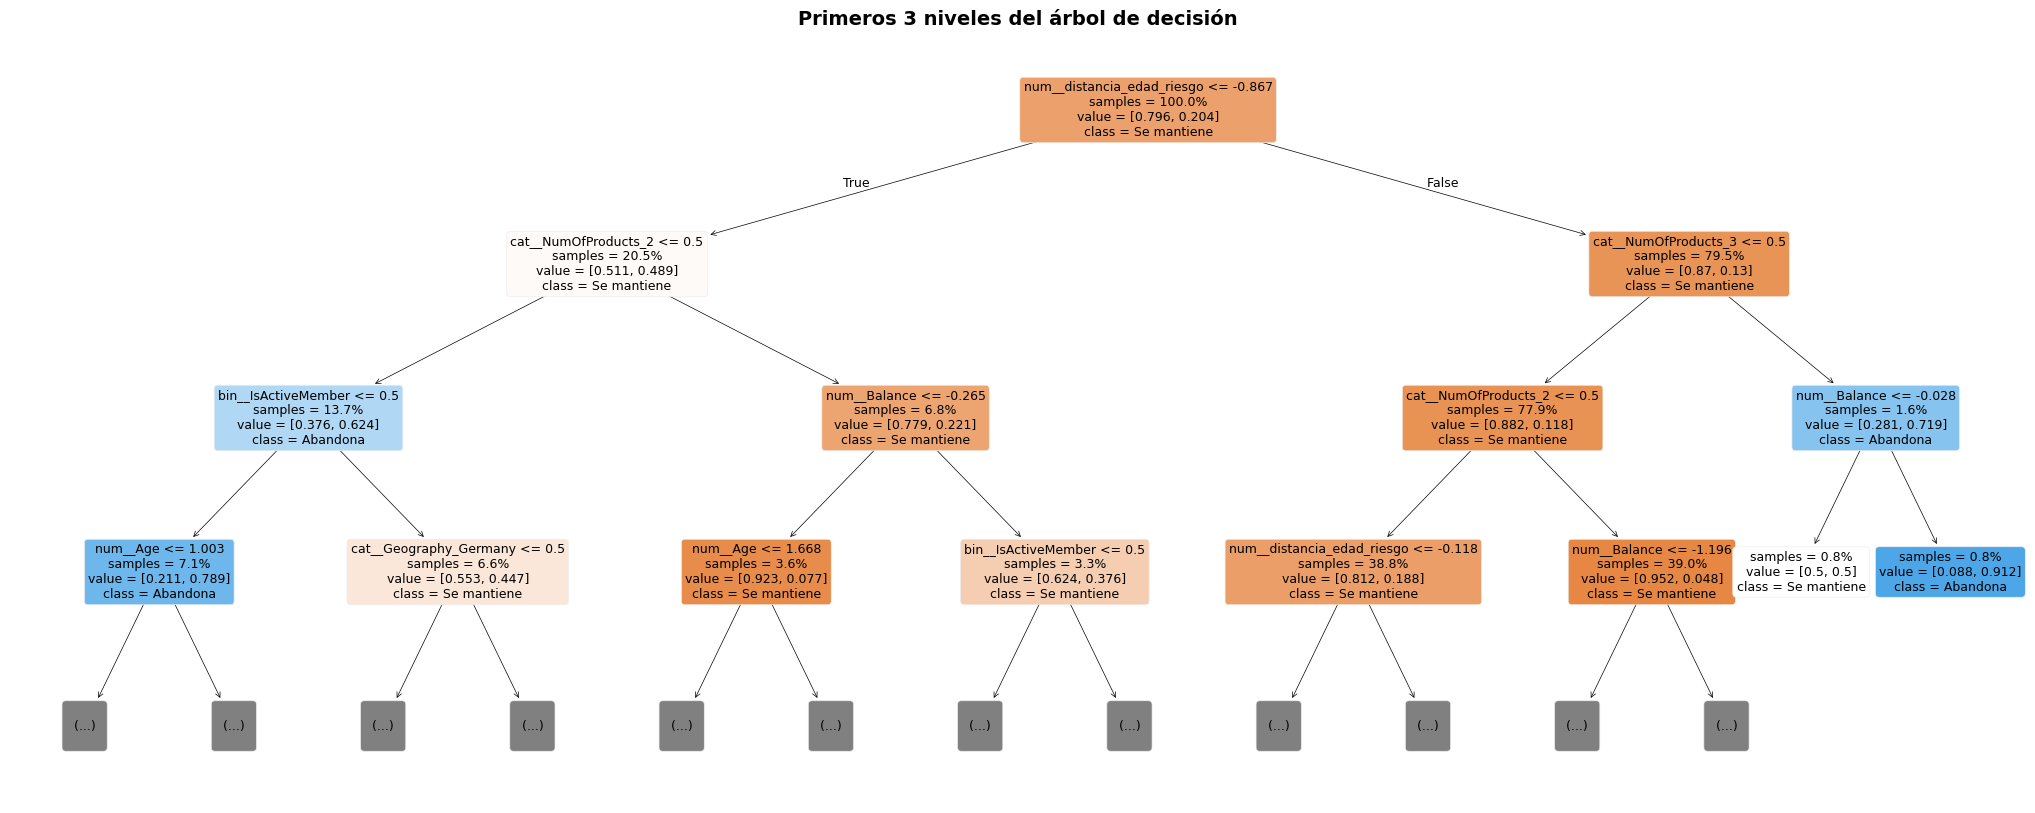

In [13]:
arbol = modelos_clasificacion['Árbol de decisión']
nombres_columnas = arbol.named_steps['preparacion'].transform(X_train.head()).columns

fig, ax = plt.subplots(figsize=(26, 10))
plot_tree(arbol.named_steps['modelo'], max_depth=3, feature_names=list(nombres_columnas),
          class_names=['Se mantiene', 'Abandona'], filled=True, rounded=True, proportion=True,
          impurity=False, fontsize=9, ax=ax)
ax.set_title('Primeros 3 niveles del árbol de decisión', fontsize=14, fontweight='bold')
plt.savefig('../images/clasificacion_arbol_decision.png', dpi=150, bbox_inches='tight')
plt.show()

Las reglas de las variables numéricas aparecen en valores estandarizados, porque el árbol trabaja
con los datos después de StandardScaler. Traducidas a unidades reales, las primeras reglas son:

- **Primera pregunta: ¿el cliente tiene entre 44,5 y 65,5 años?** (distancia_edad_riesgo ≤ 10,5
  años). Es la regla más importante del árbol, igual que en el EDA, donde la edad fue el factor más
  relacionado con el abandono.
  - **Sí (20,5% de los clientes, 49% abandona):** se pregunta si **no** tiene 2 productos, y luego si
    está inactivo. Un cliente de esa edad, sin 2 productos e **inactivo**, abandona el **79%** de las
    veces (7,1% de los clientes).
  - **No (79,5% de los clientes, 13% abandona):** se pregunta si tiene **3 productos**. Los que tienen
    3 abandonan el 72% de las veces, aunque son pocos (1,6% de los clientes).
- Más abajo aparecen el saldo (cortes en ~60.000 y ~75.000), la edad exacta (~50 y ~57 años) y ser
  de Alemania.

Las reglas coinciden con los hallazgos del EDA: la edad, la cantidad de productos y la actividad son
las variables que más separan a los clientes que abandonan. Es una forma de mostrar al negocio
**cómo** decide un modelo, algo que el Random Forest (cientos de árboles promediados) no permite.

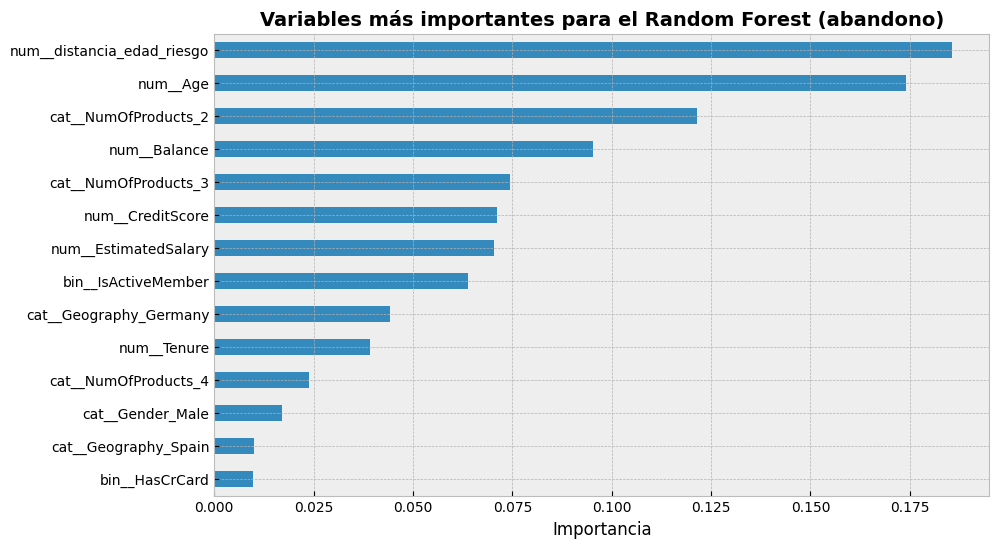

In [14]:
random_forest = modelos_clasificacion['Random Forest']
columnas_modelo = random_forest.named_steps['preparacion'].transform(X_train.head()).columns

importancia = pd.Series(random_forest.named_steps['modelo'].feature_importances_,
                        index=columnas_modelo).sort_values()

importancia.plot(kind='barh', figsize=(10, 6))
plt.title('Variables más importantes para el Random Forest (abandono)', fontsize=14, fontweight='bold')
plt.xlabel('Importancia')
plt.savefig('../images/importancia_variables_clasificacion.png', dpi=150, bbox_inches='tight')
plt.show()

La importancia muestra qué tanto usa el Random Forest cada variable para decidir:

- **distancia_edad_riesgo** y **Age** son las más usadas: coincide con el EDA, donde la edad fue
  el factor más relacionado con el abandono (Sección 4.3).
- **Tener 2 productos** (cat__NumOfProducts_2) es la tercera y **tener 3 productos** la quinta:
  coincide con el efecto de la cantidad de productos del EDA (Sección 4.2).
- **Balance** es la cuarta.

Hay que leer este gráfico con cuidado: esta forma de medir la importancia favorece a las
variables numéricas con muchos valores distintos, y más aún con los árboles profundos que eligió
el ajuste (hojas de 1 cliente). Por eso CreditScore y EstimatedSalary aparecen en sexto y séptimo
lugar, por encima de IsActiveMember y Geography_Germany, aunque el EDA mostró que no cambian el
abandono (Sección 4.7).

# Paso 3 — Regresión: estimar el saldo (Balance)

**Variable objetivo:** Balance. **Características:** el resto de las variables, excluyendo
Balance y lo que se calcula a partir de él (tiene_saldo). También se excluye Exited: el
abandono ocurre después del saldo observado, así que no es un dato disponible al momento de
estimar el saldo de un cliente actual. Se usa la misma partición entrenamiento/prueba.

Se comparan dos modelos:

- **Regresión lineal:** modelo lineal simple, punto de partida. No tiene hiperparámetros que
  ajustar (los coeficientes se calculan directamente de los datos).
- **Random Forest:** puede captar relaciones que no son lineales, como la de la cantidad de
  productos con el saldo (EDA, Sección 5.3). Sus hiperparámetros se ajustan con
  **RandomizedSearchCV**, con el mismo espacio de búsqueda que en clasificación, ampliado a hojas
  más grandes (hasta 60 clientes) porque el saldo es un target con mucho ruido.

**Métricas:**

- **MAE** (error absoluto medio): cuánto se equivoca el modelo en promedio, en la misma unidad
  que Balance.
- **RMSE:** como el MAE, pero castiga más los errores grandes.
- **R²:** qué parte de la variación del saldo explica el modelo (0 = nada, 1 = todo).

**Líneas base.** Un modelo solo es útil si se equivoca menos que una predicción constante. Pero la
mejor constante depende de la métrica: el valor que minimiza el MAE es la **mediana**, y el que
minimiza el RMSE (y deja el R² en 0) es el **promedio**. Se incluyen las dos, y cada métrica se
compara con su línea base: el MAE con la mediana; el RMSE y el R² con el promedio.

Igual que en clasificación, **el modelo se elige con validación cruzada de 5 partes sobre el
entrenamiento** y la prueba se usa una sola vez, al final.

## 3.1 Elección del modelo con validación cruzada, con y sin los países

El EDA mostró que ser de Alemania es la variable más relacionada con el saldo (correlación 0,40,
Sección 3.3), pero que esa relación probablemente se debe a cómo se armó la muestra: ningún
cliente alemán tiene saldo 0 (Sección 2.7). Si el modelo se apoya en ese patrón, sus métricas se
verán mejores de lo que serían con clientes reales.

Para medirlo, cada modelo se evalúa en dos versiones: **con** la variable Geography y **sin** ella.
El Random Forest se ajusta por separado en cada versión, porque los mejores hiperparámetros pueden
cambiar al quitar una variable.

In [15]:
cv_reg = KFold(n_splits=5, shuffle=True, random_state=SEMILLA)
metricas_reg = {'MAE': 'neg_mean_absolute_error', 'RMSE': 'neg_root_mean_squared_error', 'R2': 'r2'}
versiones = {
    'con países': features_cat,
    'sin países': [col for col in features_cat if col != 'Geography'],
}
espacio_rf_reg = {
    'modelo__n_estimators':     randint(200, 601),
    'modelo__max_depth':        [None, 4, 6, 8, 12],
    'modelo__min_samples_leaf': randint(1, 61),
    'modelo__max_features':     ['sqrt', 0.3, 0.5, 0.7, 1.0],
}


def fila_cv(modelo, version, resultados, indice=None):
    """
    Resume una validación cruzada: media de cada métrica en las particiones (en positivo) y
    desviación del R². Acepta la salida de cross_validate (indice=None) o el cv_results_ de una
    búsqueda (indice = posición de la mejor combinación).
    """
    fila = {'modelo': modelo, 'version': version}
    for metrica in metricas_reg:
        if indice is None:
            puntajes = resultados[f'test_{metrica}']
        else:
            puntajes = np.array([resultados[f'split{k}_test_{metrica}'][indice]
                                 for k in range(cv_reg.get_n_splits())])
        puntajes = puntajes if metrica == 'R2' else -puntajes   # sklearn reporta los errores en negativo
        fila[metrica] = puntajes.mean()
        if metrica == 'R2':
            fila['R2 (desv.)'] = puntajes.std()
    return fila


filas = []
for nombre, estrategia in [('Línea base (mediana)', 'median'), ('Línea base (promedio)', 'mean')]:
    resultados = cross_validate(DummyRegressor(strategy=estrategia), X_train, y_reg_train,
                                cv=cv_reg, scoring=metricas_reg)
    filas.append(fila_cv(nombre, '-', resultados))

busquedas_reg = {}
for version, categoricas in versiones.items():
    lineal = cross_validate(modelo_completo(features_num_reg, categoricas, features_bin_reg, LinearRegression()),
                            X_train, y_reg_train, cv=cv_reg, scoring=metricas_reg)
    filas.append(fila_cv('Regresión lineal', version, lineal))

    busqueda = RandomizedSearchCV(
        modelo_completo(features_num_reg, categoricas, features_bin_reg, RandomForestRegressor(random_state=SEMILLA)),
        param_distributions=espacio_rf_reg, n_iter=30,
        scoring=metricas_reg, refit='MAE', cv=cv_reg, n_jobs=-1, random_state=SEMILLA,
    )
    busqueda.fit(X_train, y_reg_train)
    busquedas_reg[version] = busqueda
    filas.append(fila_cv('Random Forest', version, busqueda.cv_results_, busqueda.best_index_))

for version, busqueda in busquedas_reg.items():
    print(f'Random Forest {version}, mejor combinación: {busqueda.best_params_}')
pd.DataFrame(filas).set_index(['modelo', 'version']).round(3)

Random Forest con países, mejor combinación: {'modelo__max_depth': 6, 'modelo__max_features': 1.0, 'modelo__min_samples_leaf': 2, 'modelo__n_estimators': 543}
Random Forest sin países, mejor combinación: {'modelo__max_depth': 6, 'modelo__max_features': 1.0, 'modelo__min_samples_leaf': 2, 'modelo__n_estimators': 543}


,,MAE,RMSE,R2,R2 (desv.)
modelo,version,,,,
Línea base (mediana),-,54499.293,65646.891,-0.111,0.020
Línea base (promedio),-,56587.960,62307.857,-0.001,0.001
Regresión lineal,con países,44899.929,52790.340,0.281,0.013
Random Forest,con países,41320.640,51360.679,0.320,0.015
Regresión lineal,sin países,49999.211,57966.045,0.134,0.021
Random Forest,sin países,49935.820,58030.603,0.132,0.017


**Líneas base.** Cada una gana en su propia métrica: la mediana tiene el menor MAE (54.499 contra
56.588) y el promedio, el menor RMSE (62.308 contra 65.647) y un R² de 0. Usar el promedio como
referencia del MAE habría exagerado la mejora de los modelos.

**Con países:**

- El **Random Forest** es el mejor modelo: MAE 41.321 y R² 0,320 (± 0,015), contra 44.900 y 0,281
  de la regresión lineal. Su MAE es un 24% menor que el de la línea base de mediana.
- El ajuste eligió árboles poco profundos (max_depth = 6) que consideran todas las variables en
  cada división (max_features = 1.0): la parte predecible del saldo es simple.

**Sin países:**

- Los dos modelos pierden más de la mitad de su R² (0,320 → 0,132 en el Random Forest y 0,281 →
  0,134 en la regresión lineal) y quedan prácticamente empatados: sin el país, las relaciones que
  quedan (sobre todo la cantidad de productos) son simples, y un modelo lineal las capta igual de
  bien.
- Siguen siendo mejores que la línea base, pero su MAE es solo un 8% menor (~49.950 contra 54.499).
- El ajuste eligió la misma combinación de hiperparámetros en las dos versiones.

**Decisión:** el modelo final es el **Random Forest con países**, el de mejores métricas con este
dataset. Pero más de la mitad de su desempeño viene de distinguir a los clientes alemanes (todos
con saldo) del resto, un patrón que probablemente se debe a cómo se armó la muestra. Por eso la
versión sin países se conserva como referencia de lo que el modelo lograría con clientes reales.

## 3.2 Evaluación final en el conjunto de prueba

Se evalúa una sola vez en la prueba el modelo elegido, el **Random Forest con países**, junto con su
versión **sin países**, que es la referencia de desempeño honesto, y las dos líneas base. Cada
búsqueda ya reentrenó su mejor combinación con todo el conjunto de entrenamiento.

In [16]:
modelos_regresion = {
    'Línea base (mediana)':        DummyRegressor(strategy='median').fit(X_train, y_reg_train),
    'Línea base (promedio)':       DummyRegressor(strategy='mean').fit(X_train, y_reg_train),
    'Random Forest (con países)':  busquedas_reg['con países'].best_estimator_,
    'Random Forest (sin países)':  busquedas_reg['sin países'].best_estimator_,
}

predicciones_reg = {}
filas = []
for nombre, modelo in modelos_regresion.items():
    pred = modelo.predict(X_test)
    predicciones_reg[nombre] = pred
    filas.append({
        'modelo': nombre,
        'MAE':    mean_absolute_error(y_reg_test, pred),
        'RMSE':   root_mean_squared_error(y_reg_test, pred),
        'R2':     r2_score(y_reg_test, pred),
    })

pd.DataFrame(filas).set_index('modelo').round(3)

,MAE,RMSE,R2
modelo,,,
Línea base (mediana),54786.430,65930.388,-0.103
Línea base (promedio),57090.578,62777.752,-0.000
Random Forest (con países),41229.924,51500.273,0.327
Random Forest (sin países),50446.098,58501.697,0.132


- La prueba confirma la validación cruzada: el Random Forest con países logra un MAE de 41.230 y un
  R² de 0,327 (0,320 en validación cruzada), y la versión sin países, un R² de 0,132 (igual que en
  validación cruzada).
- Cada métrica contra su línea base: el MAE baja un 25% respecto de la mediana (54.786 → 41.230), y
  el R² sube de 0 (promedio) a 0,327.
- Sin países, el MAE baja solo un 8% respecto de la mediana (54.786 → 50.446).

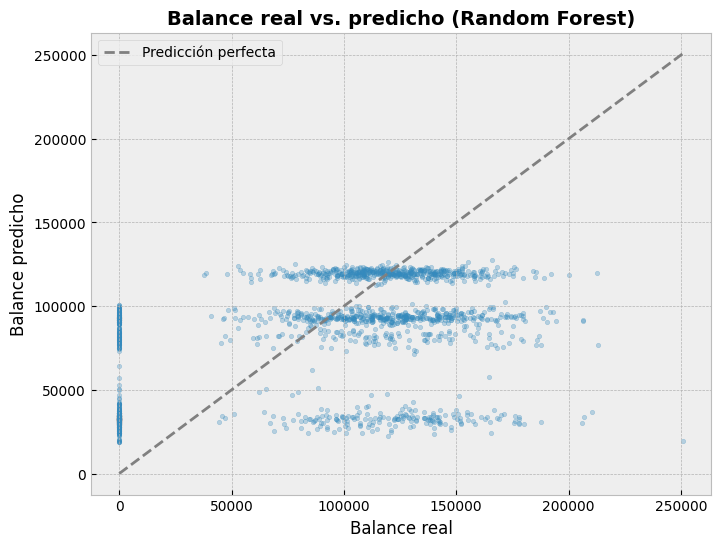

In [17]:
pred_rf = predicciones_reg['Random Forest (con países)']

plt.figure(figsize=(8, 6))
plt.scatter(y_reg_test, pred_rf, alpha=0.3, s=10)
plt.plot([0, y_reg_test.max()], [0, y_reg_test.max()], color='gray', linestyle='--', label='Predicción perfecta')
plt.title('Balance real vs. predicho (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Balance real')
plt.ylabel('Balance predicho')
plt.legend()
plt.savefig('../images/regresion_real_vs_predicho.png', dpi=150, bbox_inches='tight')
plt.show()

El gráfico muestra el problema principal: la columna de puntos en Balance real = 0 son clientes
sin saldo a los que el modelo les estima entre ~19.000 y ~101.000. El 36% de los clientes tiene
saldo 0 (EDA, Sección 5.2), y con las variables disponibles el modelo no logra distinguirlos del
resto. Las predicciones se agrupan en franjas horizontales (en torno a ~33.000, ~80.000, ~93.000 y
~120.000): el modelo estima el saldo típico de cada grupo de clientes (según país y cantidad de
productos), no el de cada cliente.

Para entender de dónde sale el R² del modelo con países, se calcula por separado para los
clientes de Alemania y los de Francia/España del conjunto de prueba:

In [18]:
es_alemania = X_test['Geography'] == 'Germany'
r2_por_grupo = pd.DataFrame({
    'con países': [r2_score(y_reg_test[es_alemania], pred_rf[es_alemania]),
                   r2_score(y_reg_test[~es_alemania], pred_rf[~es_alemania])],
    'sin países': [r2_score(y_reg_test[es_alemania], predicciones_reg['Random Forest (sin países)'][es_alemania]),
                   r2_score(y_reg_test[~es_alemania], predicciones_reg['Random Forest (sin países)'][~es_alemania])],
}, index=['Alemania', 'Francia/España'])
print('R² del Random Forest por grupo de clientes:')
r2_por_grupo.round(3)

R² del Random Forest por grupo de clientes:


,con países,sin países
Alemania,-0.008,-3.399
Francia/España,0.207,0.155


- **Con países**, el modelo no explica nada dentro de Alemania (R² ≈ -0,01): no sabe qué cliente
  alemán tiene más o menos saldo, solo que en promedio tienen más. En Francia y España explica
  el 20,7%.
- **Sin países**, el R² en Alemania cae a -3,40: el modelo ya no sabe que un cliente es alemán y le
  estima saldos bajos como a muchos franceses y españoles, cuando en realidad todos tienen saldo.
  En Francia y España baja de 0,207 a 0,155.

**¿Cuál usar?** Con los datos de este dataset, el modelo con países tiene mejores métricas. Pero
esas métricas se apoyan en un patrón que probablemente se debe a cómo se armó la muestra, así
que no reflejan lo que el modelo lograría con clientes reales. **La estimación honesta de su
desempeño es la de los resultados sin países o la de Francia y España: el modelo explica entre
un 13% y un 21% del saldo.**

## ¿Qué aprende realmente el modelo de regresión?

El EDA mostró que Balance está **inflado en cero**: el 36% de los clientes tiene saldo 0 y el
resto se concentra en torno a ~120.000 (Sección 5.2). Para entender qué capta el modelo, se
evalúa el Random Forest (con países) por separado en los clientes con saldo 0 y en los clientes
con saldo, y se mide si sus predicciones siguen al saldo real dentro de cada grupo.

In [19]:
grupo_saldo = np.where(y_reg_test > 0, 'Con saldo', 'Saldo 0')
evaluacion = pd.DataFrame({'real': y_reg_test, 'predicho': pred_rf, 'grupo': grupo_saldo})
evaluacion['error_absoluto'] = (evaluacion['real'] - evaluacion['predicho']).abs()

por_grupo = evaluacion.groupby('grupo').agg(
    clientes=('real', 'size'),
    saldo_real_promedio=('real', 'mean'),
    saldo_predicho_promedio=('predicho', 'mean'),
    MAE=('error_absoluto', 'mean'),
)
print(por_grupo.round(0), '\n')

con_saldo = y_reg_test > 0
print(f"Correlación entre predicción y saldo real (todos):             {np.corrcoef(y_reg_test, pred_rf)[0, 1]:.3f}")
print(f"Correlación entre predicción y saldo real (solo con saldo):    {np.corrcoef(y_reg_test[con_saldo], pred_rf[con_saldo])[0, 1]:.3f}")

           clientes  saldo_real_promedio  saldo_predicho_promedio      MAE
grupo                                                                     
Con saldo      1274             120729.0                  93304.0  37979.0
Saldo 0         726                  0.0                  46935.0  46935.0 

Correlación entre predicción y saldo real (todos):             0.572
Correlación entre predicción y saldo real (solo con saldo):    -0.017


- El modelo les estima en promedio **~47.000 a los clientes con saldo 0** y **~93.000 a los que
  tienen ~121.000**: separa a los dos grupos solo a medias, y se equivoca en ambos (MAE de ~47.000
  y ~38.000).
- En total, sus predicciones se relacionan con el saldo real (correlación 0,57). Pero **entre los
  clientes que tienen saldo, la correlación es prácticamente 0 (-0,02)**: el modelo no capta si un
  cliente tiene 60.000 o 180.000.

Es decir, **todo lo que el modelo aprende es a distinguir, a medias, quién tiene saldo y quién
no**. Cuánto saldo tiene un cliente no se puede predecir con las variables disponibles. Esto
cambia cómo leer el R²: no mide qué tan bien se estiman los montos, sino qué tan bien se separa a
los clientes con saldo 0 del resto.

**Conclusión para el negocio:** el objetivo de la guía, proyectar el volumen de fondos que un
cliente mantendrá en su cuenta, no se puede cumplir con estos datos. Lo que sí entrega el modelo
es una idea de qué clientes probablemente tienen fondos y cuáles no.

# Resumen

**Paso 2 — Clasificación (Exited):**

- Se compararon una regresión logística, un árbol de decisión y un Random Forest. Sus
  hiperparámetros se ajustaron con **validación cruzada estratificada de 5 partes** sobre el
  entrenamiento: **GridSearchCV** para la logística (12 combinaciones de C y penalización) y el árbol
  (35 combinaciones de profundidad y tamaño de hoja), y **RandomizedSearchCV** para el Random Forest
  (30 combinaciones de 4 hiperparámetros). El ajuste casi no cambió a la logística y mejoró al
  Random Forest en algo más de 1 punto de PR-AUC.
- Los modelos se entrenan **sin class_weight='balanced'**: esa opción no mejora el ROC-AUC y casi
  duplica el abandono estimado (0,39 contra 0,20 real). El desbalance se maneja con el umbral,
  elegido con predicciones fuera de pliegue; la prueba se usó solo para la evaluación final.
- El **Random Forest** supera a la logística en las 5 particiones (comparación pareada con prueba t
  corregida: p = 0,020 en ROC-AUC), pero por poco: +0,011 de ROC-AUC y +0,017 de PR-AUC. Al árbol de
  decisión lo supera con más claridad (+0,045 de PR-AUC, p < 0,001). En prueba logra ROC-AUC 0,862
  y PR-AUC 0,703.
- El **árbol de decisión** es el de menor rendimiento (PR-AUC 0,641 en prueba), pero el único que se
  puede leer como reglas: su primera pregunta es si el cliente tiene entre 44,5 y 65,5 años, y un
  cliente de esa edad, inactivo y sin 2 productos abandona el 79% de las veces.
- **Criterio del umbral:** priorizar el recall manteniendo una precisión de al menos 50%. El umbral
  elegido es 0,25: en prueba, el Random Forest detecta 289 de 407 abandonos (71%) y el 55% de sus
  alertas son reales (F1 = 0,620). Con el umbral de máximo F1 (0,35) habría detectado solo 242.
- El **umbral es la palanca de negocio**: con 0,20 se detecta el 76% de los abandonos alertando al
  32% de la cartera; con 0,50, el 44% alertando al 12%.
- Las variables que más usa el modelo (edad, cantidad de productos y saldo) coinciden con los
  hallazgos del EDA.

**Paso 3 — Regresión (Balance):**

- Se compararon una regresión lineal y un Random Forest (ajustado con **RandomizedSearchCV**), y el
  modelo se eligió con validación cruzada de 5 partes sobre el entrenamiento. El **Random Forest
  con países** es el mejor: en prueba, MAE = 41.230 y R² = 0,327, un 25% menos de error absoluto que
  predecir siempre la mediana (la línea base que corresponde al MAE).
- **Con y sin países:** sin la variable Geography, el R² en validación cruzada cae de 0,320 a 0,132
  (Random Forest) y de 0,281 a 0,134 (regresión lineal). Más de la mitad del desempeño venía de
  distinguir a los clientes alemanes, un patrón que probablemente se debe a cómo se armó la
  muestra. La estimación honesta es que el modelo explica entre un 13% y un 21% del saldo.
- **Lo que realmente aprende el modelo** es a distinguir, a medias, a los clientes con saldo 0 del
  resto. Entre los clientes con saldo, sus predicciones no se relacionan con el monto real
  (correlación -0,02): el volumen de fondos de un cliente no se puede proyectar con estas
  variables.
- Sirve para estimar el saldo típico de un grupo de clientes, no el saldo de un cliente en
  particular.

**Limitaciones:**

- El dataset no trae fechas (EDA, Sección 2.9). Si NumOfProducts o IsActiveMember se registraron
  después del abandono, el modelo de clasificación estaría usando información del futuro y sus
  métricas serían optimistas.
- El centro de distancia_edad_riesgo se calcula con todo el entrenamiento, incluida la parte de
  validación de cada partición. El efecto es mínimo (es un solo número, y coincide con el del EDA),
  pero vuelve levemente optimista a la validación cruzada. La prueba no se ve afectada.

**Nota ética:** el modelo de clasificación usa el género y el país. Antes de usarlo para decidir a
quién ofrecer una campaña de retención, habría que revisar si comete errores parecidos con
hombres y mujeres y entre países, para no tratar distinto a los clientes por esas características.